# Exploratory Data Analysis

This notebook asks the initial questions about the German Credit dataset and looks for patterns that may matter later in modeling.

The answers here are preliminary. The final model-based conclusions are in notebook 03.

## Research Questions

- What is the class distribution?
- Which features seem most related to default risk?
- Are there missing values, duplicates, skewness, or outliers?
- What preprocessing will likely be needed before modeling?

## Import and inspect the data

Import the data into the evaluation environment

It's critical to look into the statistics, so you can gain initial know-how of its structure, variable kinds, and potential issues

Here are a few tasks:
- Load the data, ensuring it is imported efficiently and without errors
- Examine the size of the data (number of rows and columns) to assess its size
- Identify data types and formats
- Look for any apparent errors or inconsistencies in the information, such as invalid values, mismatched units, or outliers.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
import os
from sklearn.datasets import fetch_openml

DATA_PATH = '../data/raw/credit_g.csv'

if not os.path.exists(DATA_PATH):
    raw = fetch_openml('credit-g', version=1, as_frame=True)
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    raw.frame.to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH, dtype={'class': 'category'})
df = df.rename(columns={'class': 'target'})


We download from OpenML, or load it if we already downloaded it

Let's take a first look at the data

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   str     
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   str     
 3   purpose                 1000 non-null   str     
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   str     
 6   employment              1000 non-null   str     
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   str     
 9   other_parties           1000 non-null   str     
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   str     
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   str     
 14  housing                 1000 non-nul

In [44]:
df.shape # 20 features, the 1 last one is the target variable 

(1000, 21)

In [45]:
df.describe(include='all').T.sort_values('unique', ascending=False)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
purpose,1000,10,radio/tv,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_history,1000,5,existing paid,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
savings_status,1000,5,<100,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment,1000,5,1<=X<4,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checking_status,1000,4,no checking,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
personal_status,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_magnitude,1000,4,car,332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job,1000,4,skilled,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_parties,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_payment_plans,1000,3,none,814,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Some questions

What we want to know?

We want to answer some questions, like:
1. What is the class distribution?
2. Which features are most informative for risk?
3. Are there data quality issues?
4. What preprocessing is justified?
5. Which baseline models perform best?

What info do we have?

We have personal info, such as the gender, age, social status, residence, etc. Also about their jobs and finance status, like savings, credit history, job, etc. And some about the credit they are asking, like purpose and amount.

How many info do we have?

We have a complete dataset with: 1000 rows, and each one corresponds to a person. Each row has 20 variables (some nominal, some numeral) and a label (if they are good or bad payer)

Is there something important" we should know?

Yes, a bad payer costs the bank around 5 times more than good payers

## Data quality

We search for missing values, duplicates, outliers for each variable

In [46]:
df.isnull().sum().sum()

np.int64(0)

In [47]:
df.duplicated().sum()

np.int64(0)

No missing values nor duplicated, let's seek outliers

<Axes: xlabel='target'>

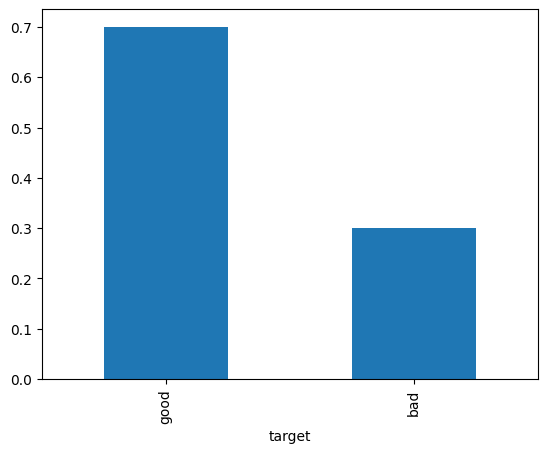

In [48]:
# Class imbalance: 700 good vs 300 bad
df['target'].value_counts(normalize=True).plot(kind='bar')

There is an imbalance between the target classes. 70% good / 30% bad

We will need to consider class_weight or resampling later when modeling

In [49]:
num_cols = df.select_dtypes(['float64', 'int64']).columns

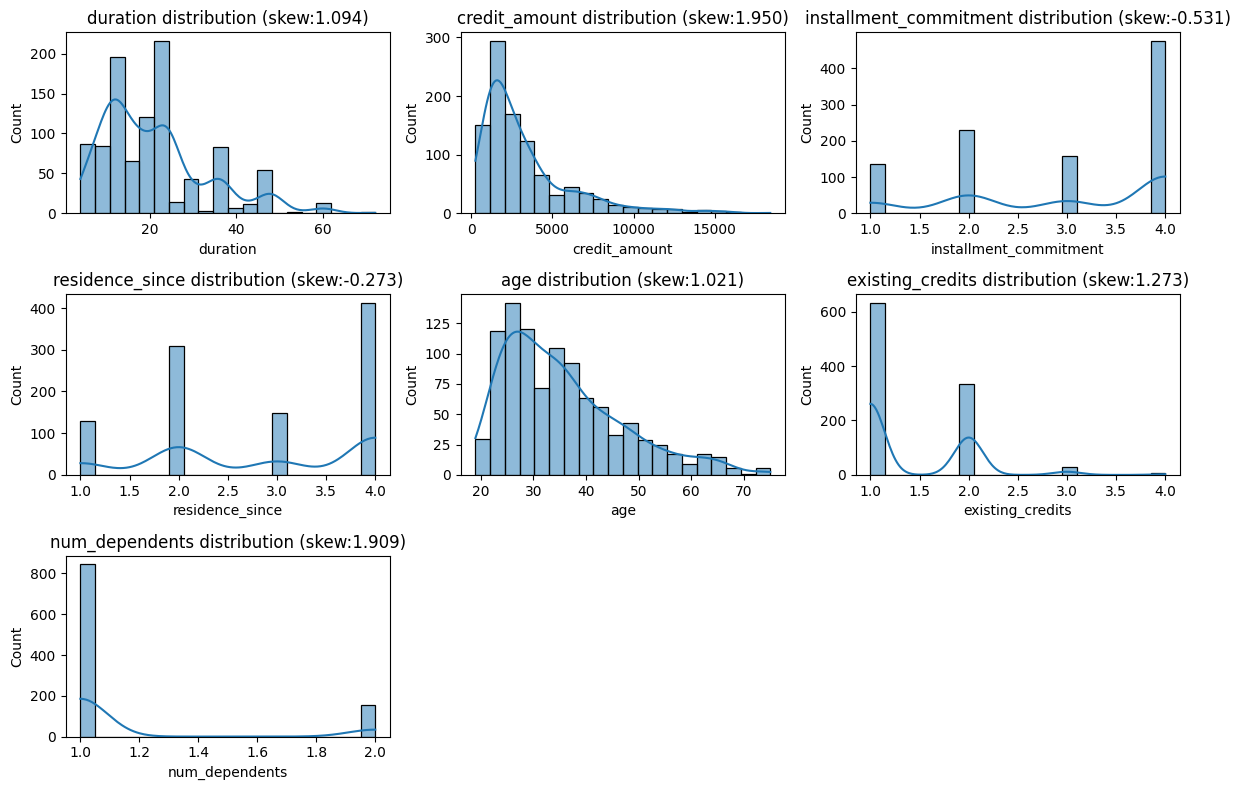

In [50]:
plt.figure(figsize=(12,8))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], bins=20, kde=True)
    plt.title(f'{feature} distribution (skew:{df[feature].skew():.3f})')
plt.tight_layout()
plt.show()

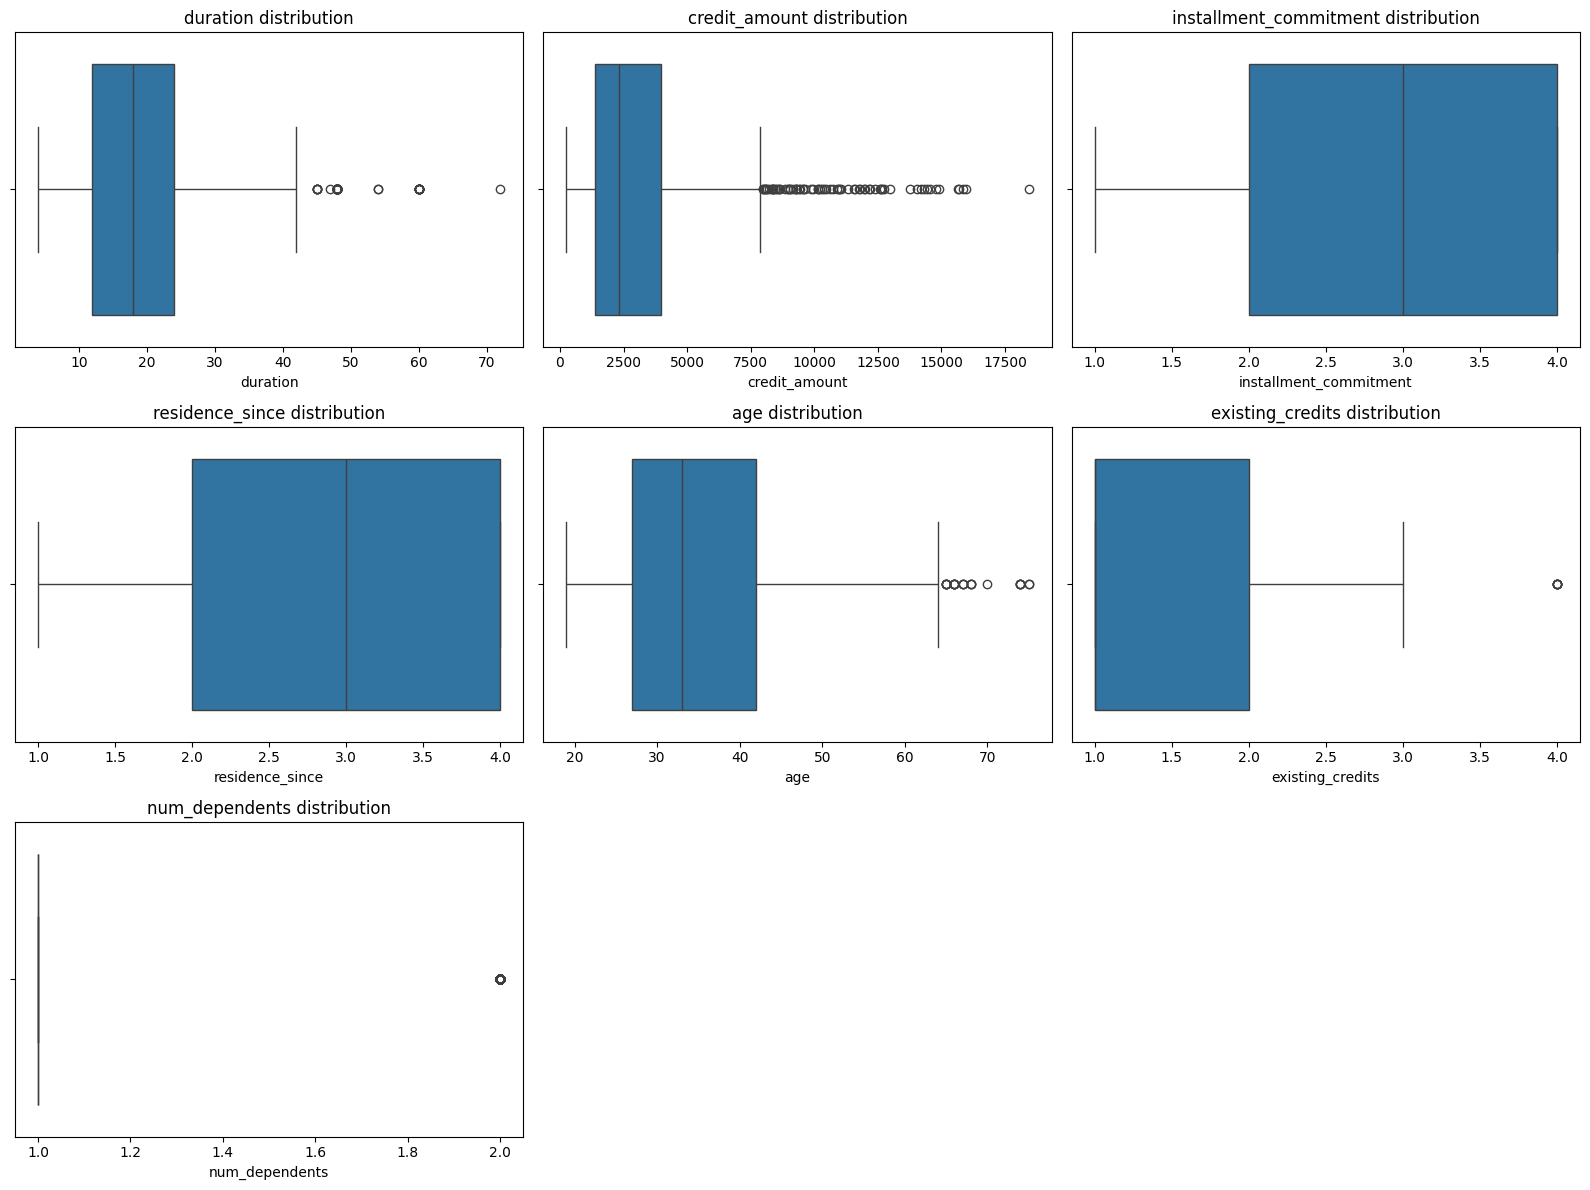

In [51]:
plt.figure(figsize=(16,12))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[feature])
    plt.title(f'{feature} distribution')
plt.tight_layout()
plt.show()

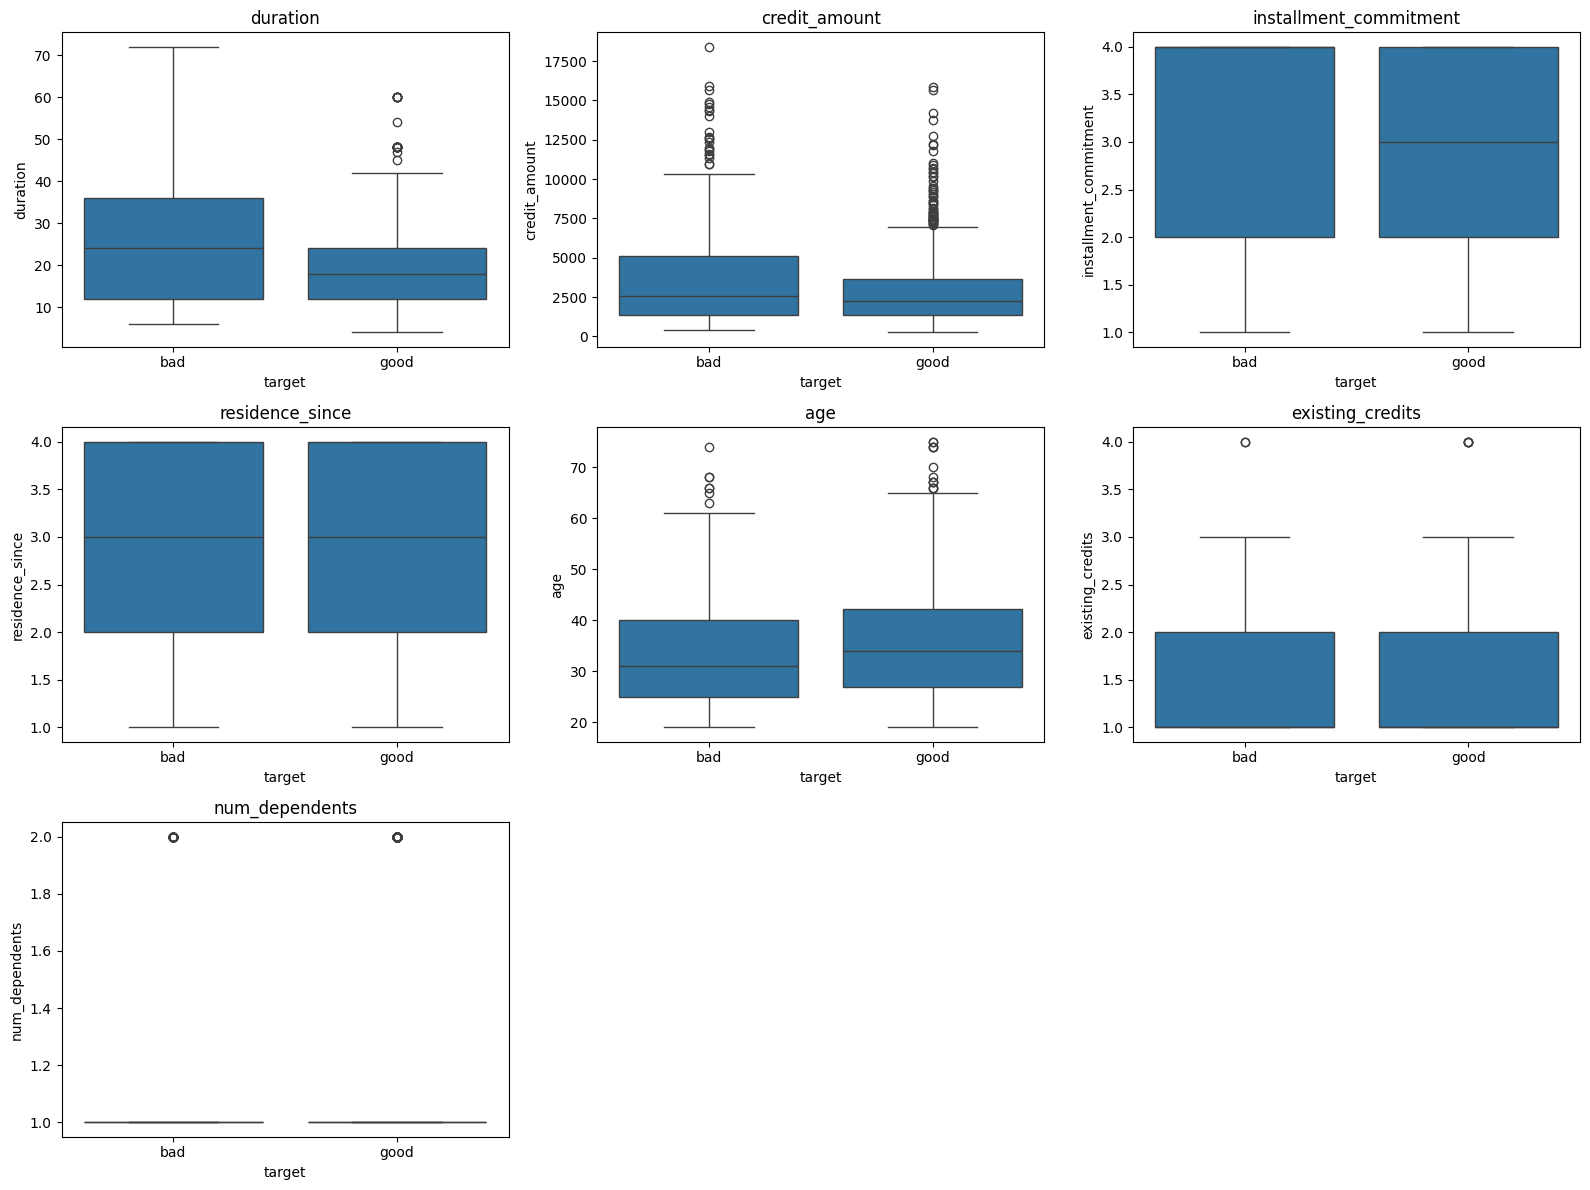

In [52]:
plt.figure(figsize=(16,12))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df['target'], y=df[feature])
    plt.title(f'{feature}')
plt.tight_layout()
plt.show()

We can see that bad payers' credits tend to have larger durations

In [53]:
# Para cada variable categórica: frecuencia + tasa de bad payers por categoría
cat_cols = df.select_dtypes(include='object').columns

/tmp/ipykernel_74687/1723203248.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


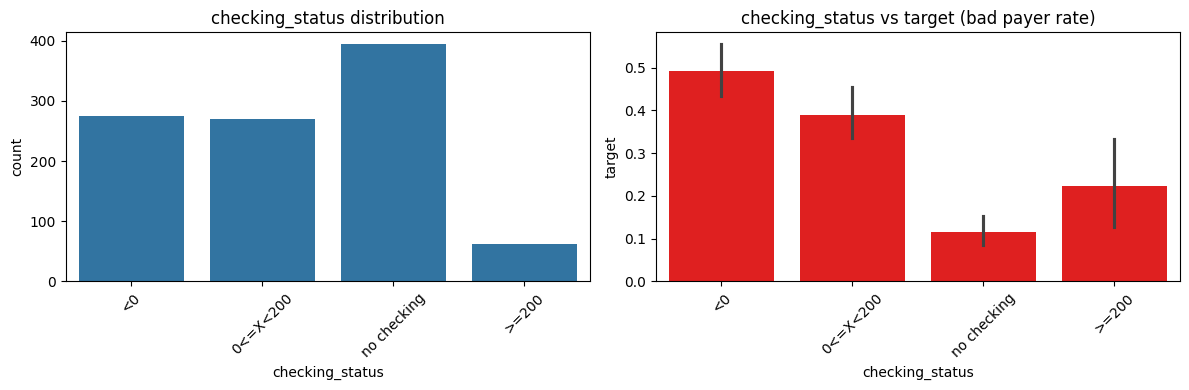

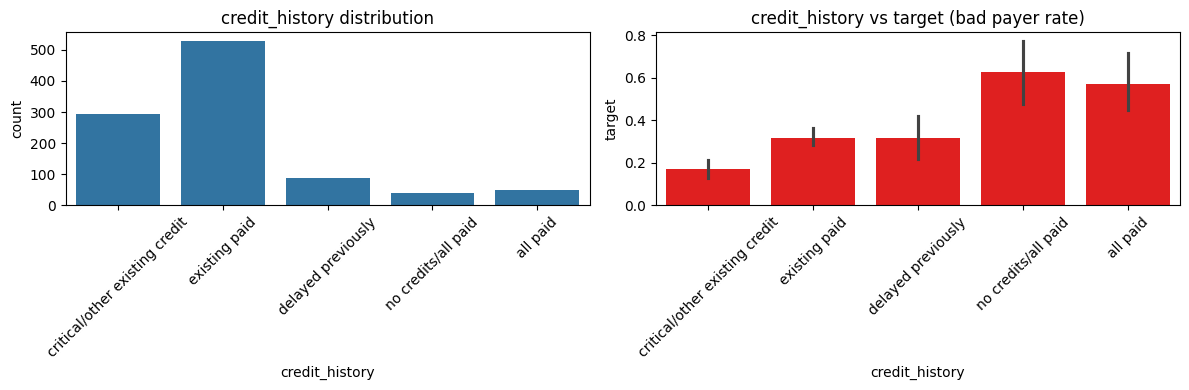

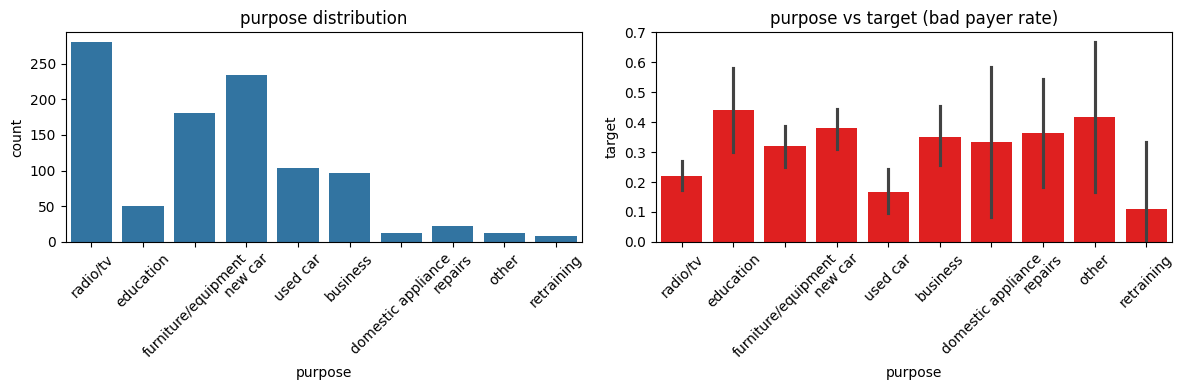

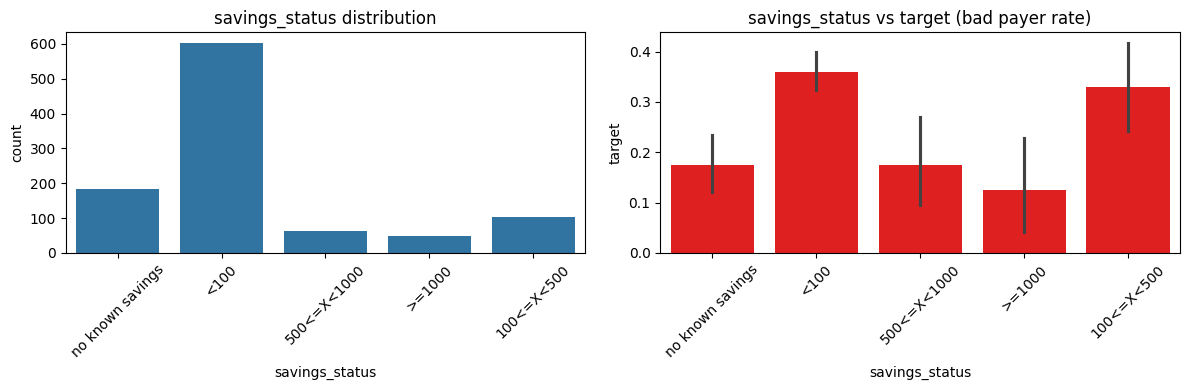

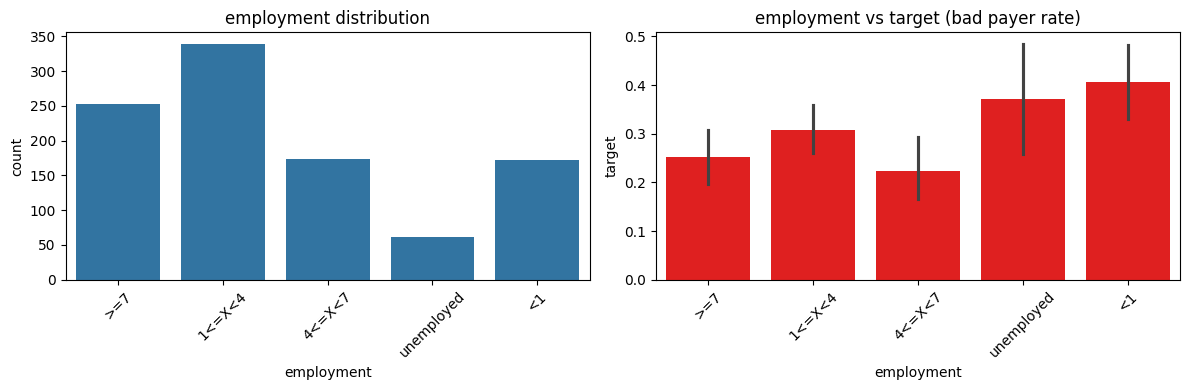

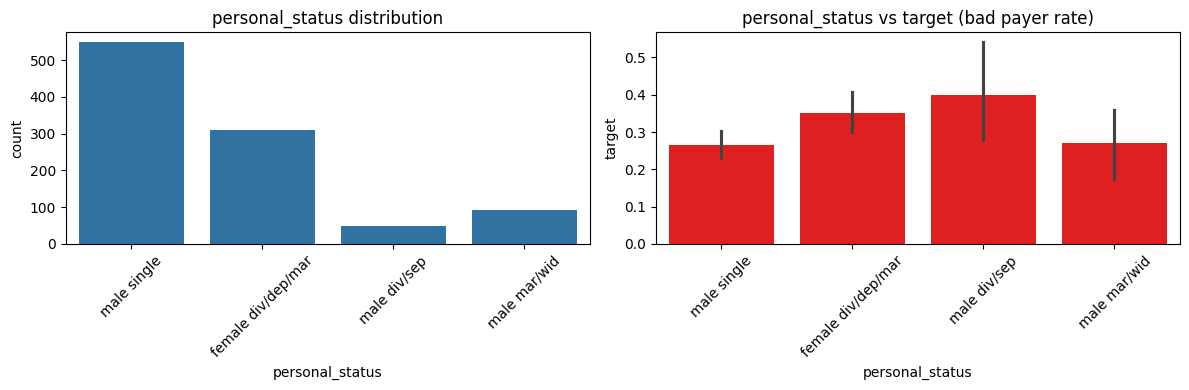

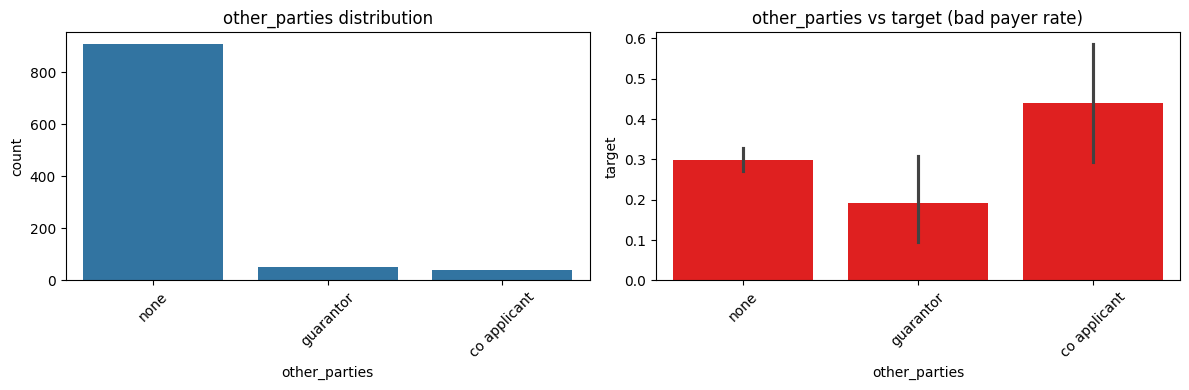

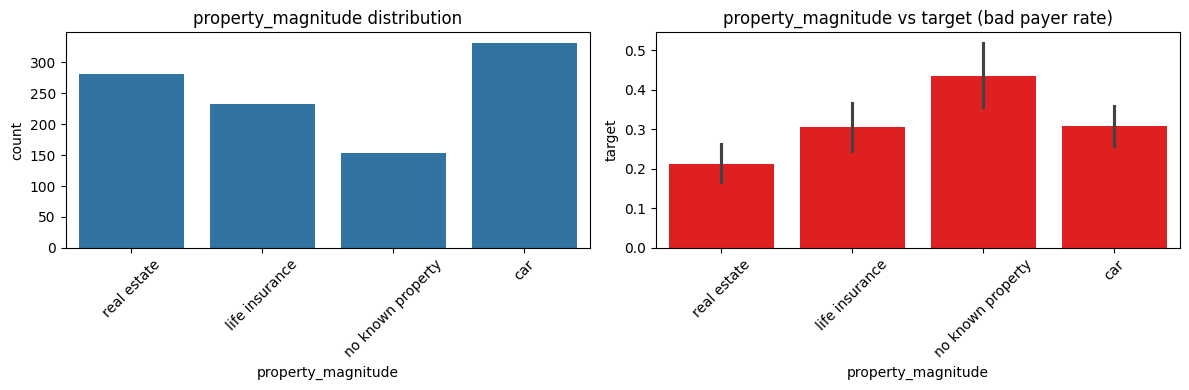

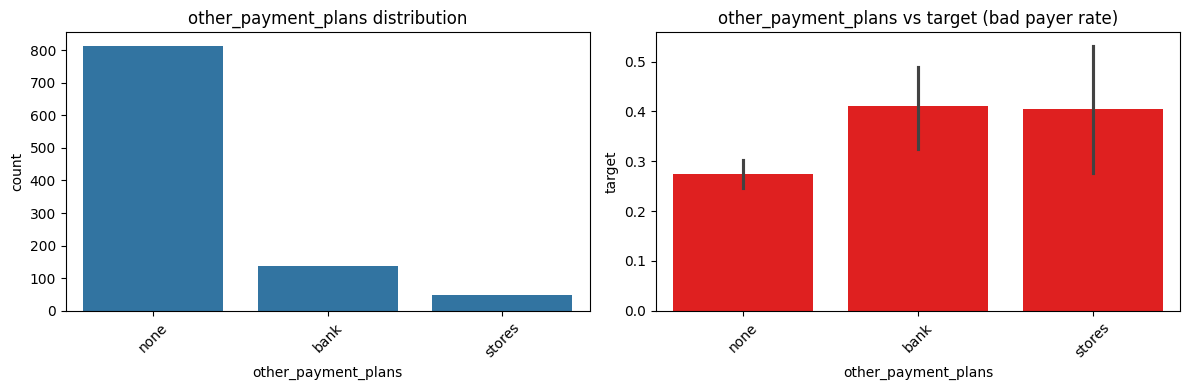

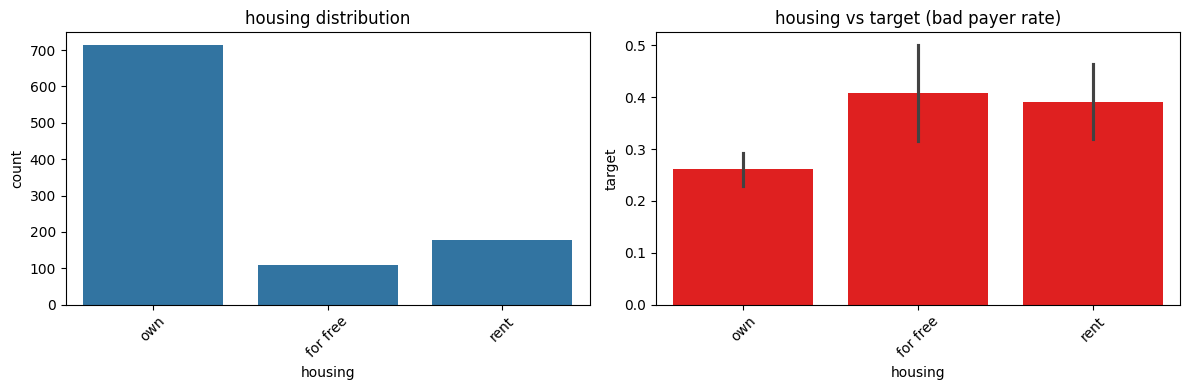

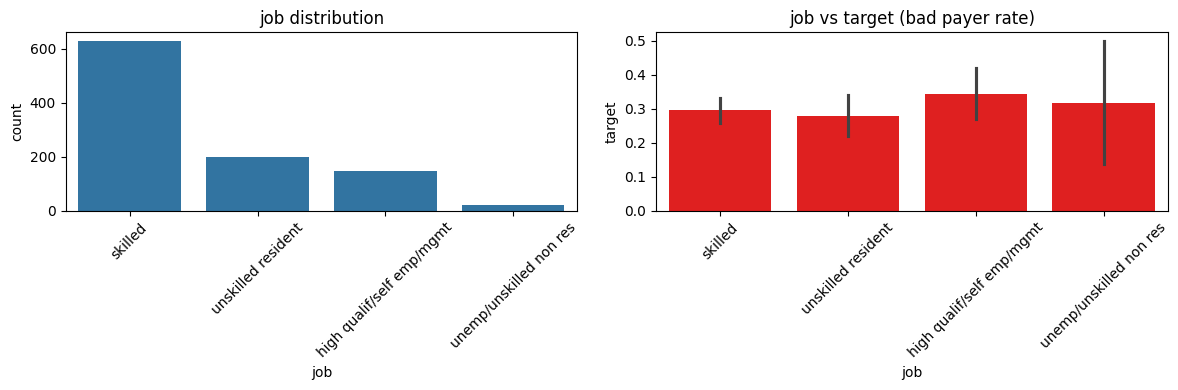

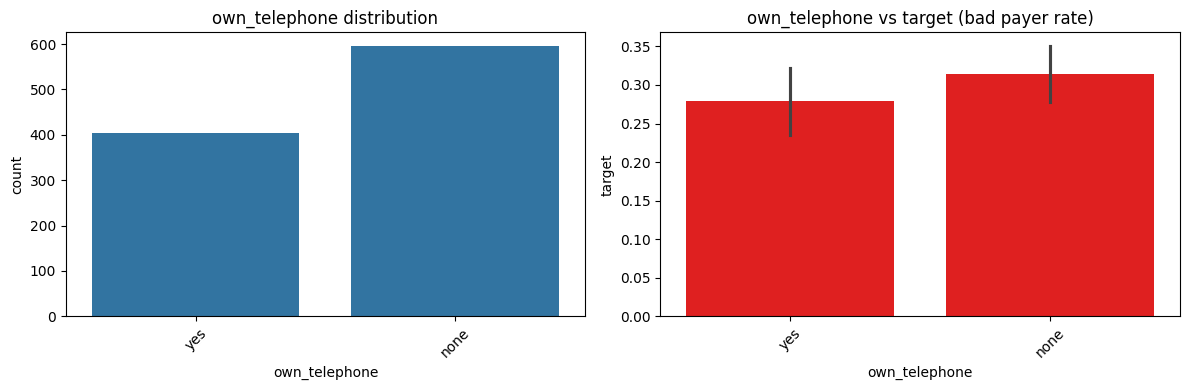

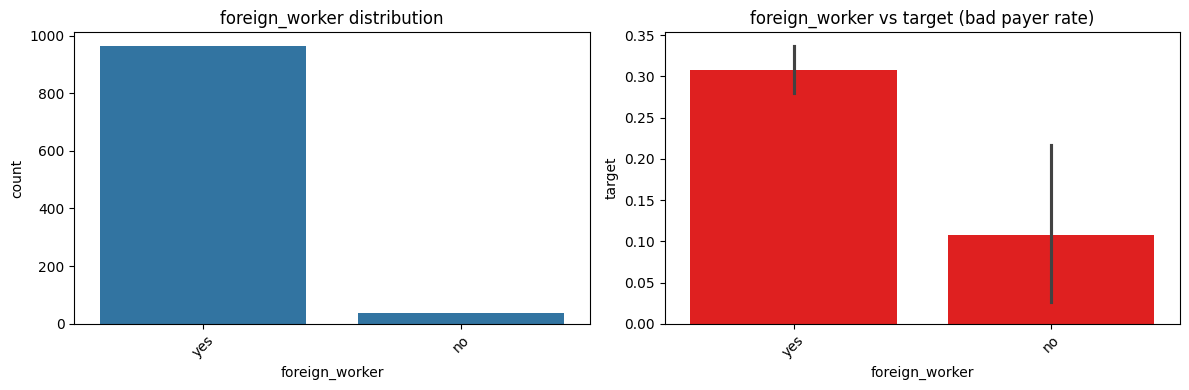

In [54]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.countplot(x=df[col], ax=axes[0])
    sns.barplot(x=df[col], y=(df['target'] == 'bad').astype(int), ax=axes[1], color='red')
    
    axes[0].set_title(f'{col} distribution')
    axes[1].set_title(f'{col} vs target (bad payer rate)')

    axes[0].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [55]:
df['credit_amount'].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: credit_amount, dtype: float64

With this info and the graphics, we notice that `credit_amount` is skewed, and the majority of credits are between $1300 and $4000 (Q1 and Q3)

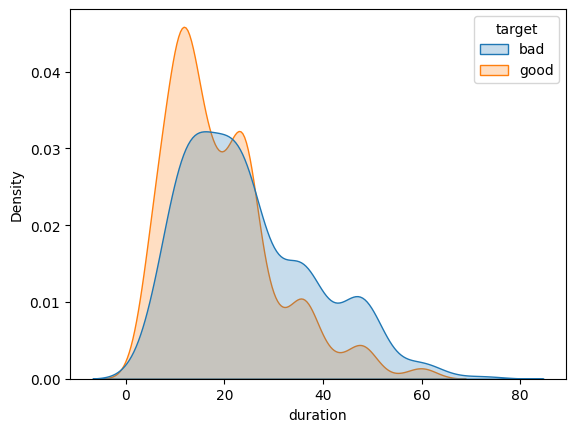

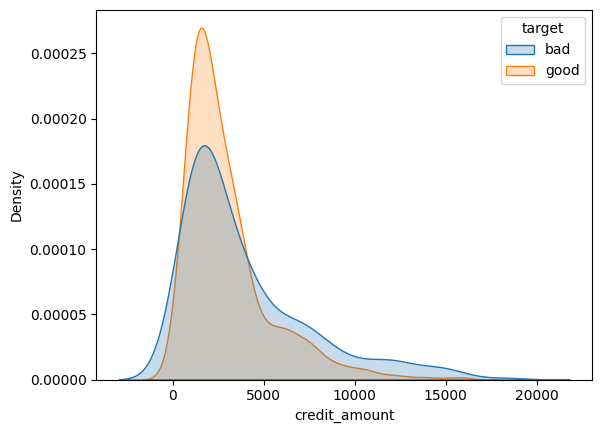

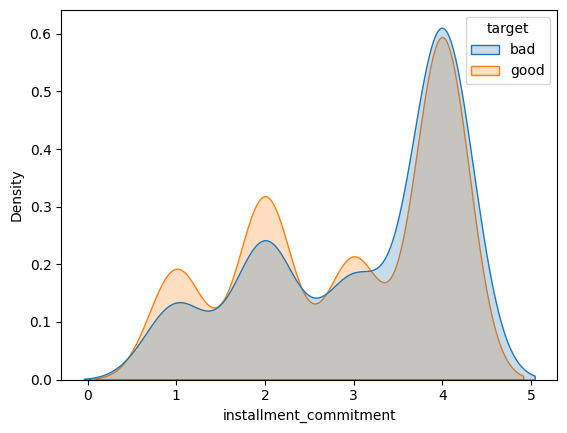

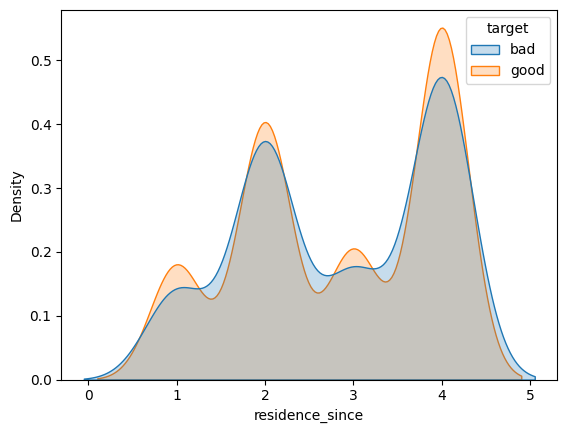

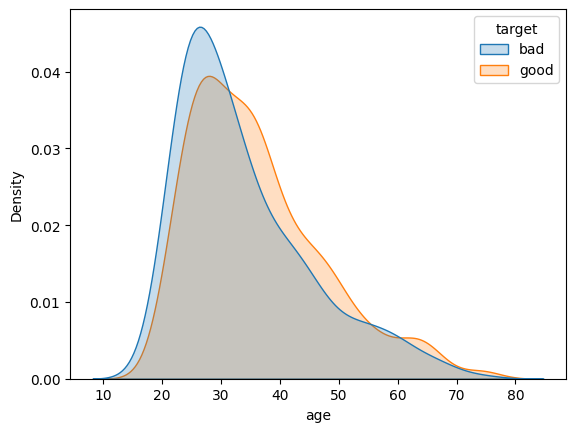

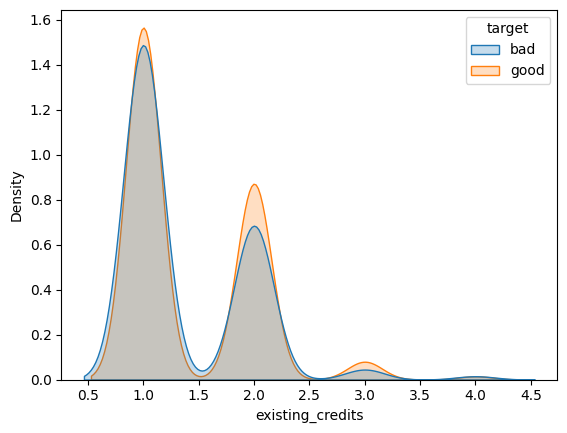

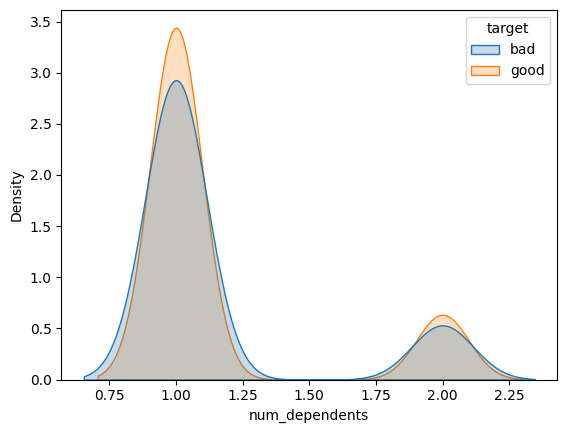

In [56]:
for col in num_cols:
    sns.kdeplot(data=df, x=col, hue='target', fill=True, common_norm=False)
    # common_norm=False normalizes the distribution of each class separately, so that the area under the curve for each class sums to 1
    # This allows us to compare the shapes of the distributions without being affected by class imbalance
    plt.show()

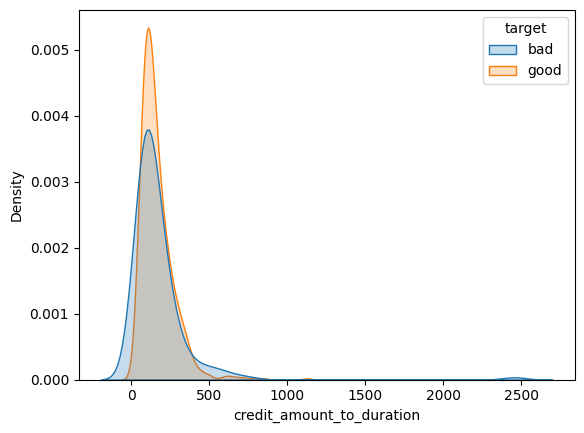

In [57]:
# Experimenting with attribute combinations numerically

df['credit_amount_to_duration'] = df['credit_amount'] / df['duration']
df['credit_amount_to_duration'].describe()
df['credit_amount_to_duration'].skew()
sns.kdeplot(data=df, x='credit_amount_to_duration', hue='target', fill=True, common_norm=False)
plt.show()

We notice a slight difference betwen classes, but it does not separate it better enough to conclude something

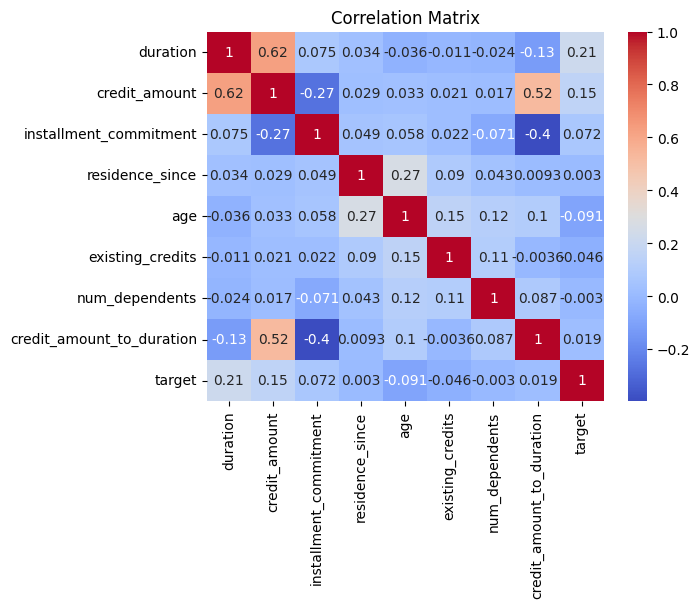

In [58]:
corr_df = df.select_dtypes(['int64', 'float64']).copy()
corr_df['target'] = (df['target'] == 'bad').astype('int64')

corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [59]:
corr_matrix['target'].sort_values(ascending=False)

target                       1.000000
duration                     0.214927
credit_amount                0.154739
installment_commitment       0.072404
credit_amount_to_duration    0.018592
residence_since              0.002967
num_dependents              -0.003015
existing_credits            -0.045732
age                         -0.091127
Name: target, dtype: float64

The correlation matrix helps us to identify which features are more correlated with the target variable, and also to identify multicollinearity between features.

In this case, we can see that 'duration' and 'credit_amount' are the most correlated with the target variable.

We can also see that there is a high correlation between 'duration' and 'credit_amount', which could indicate multicollinearity.

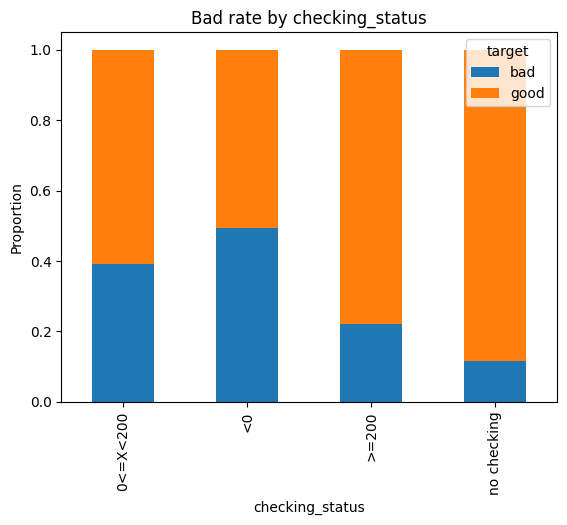

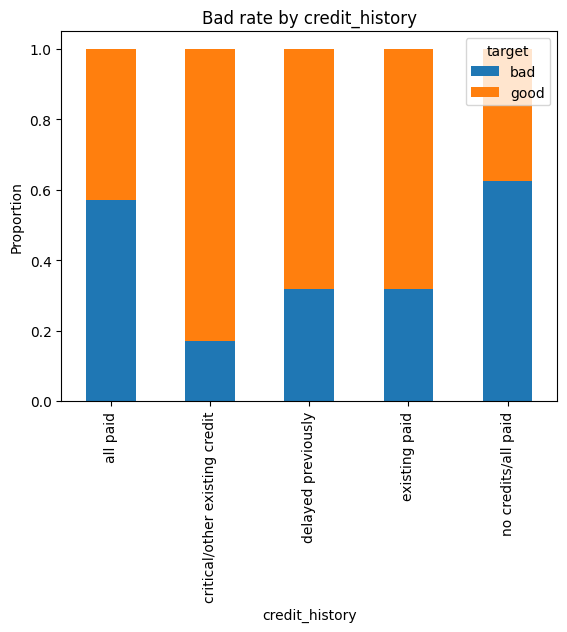

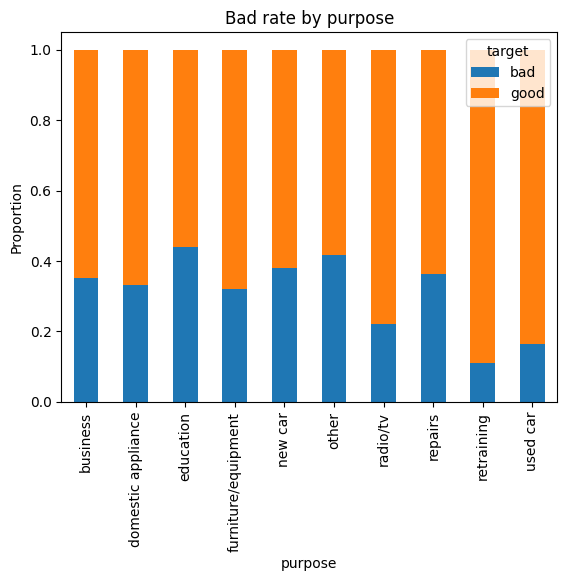

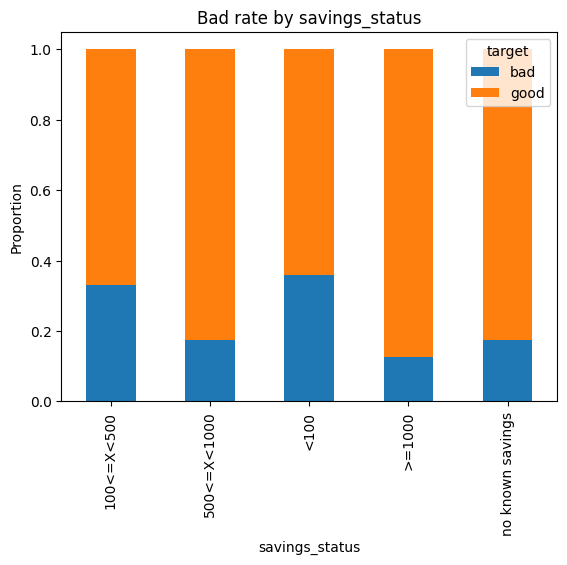

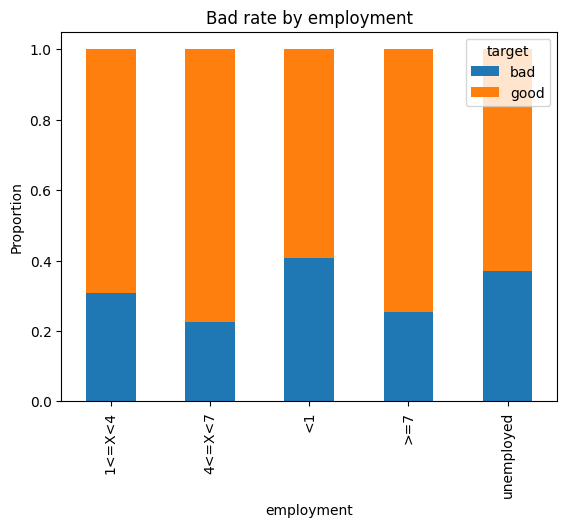

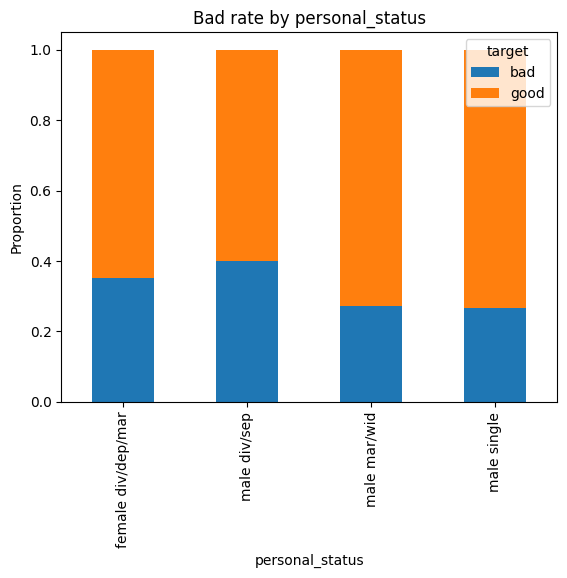

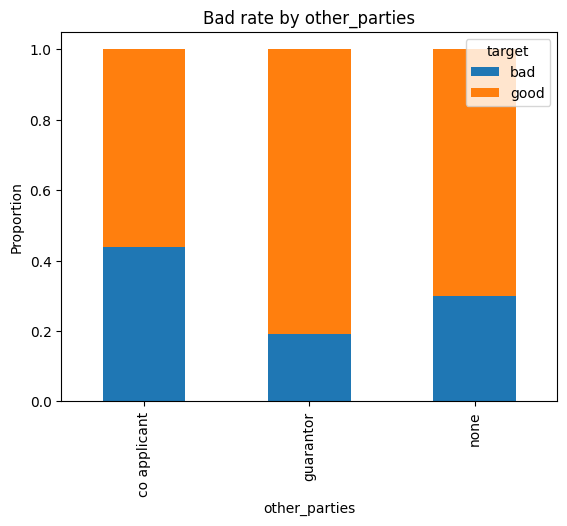

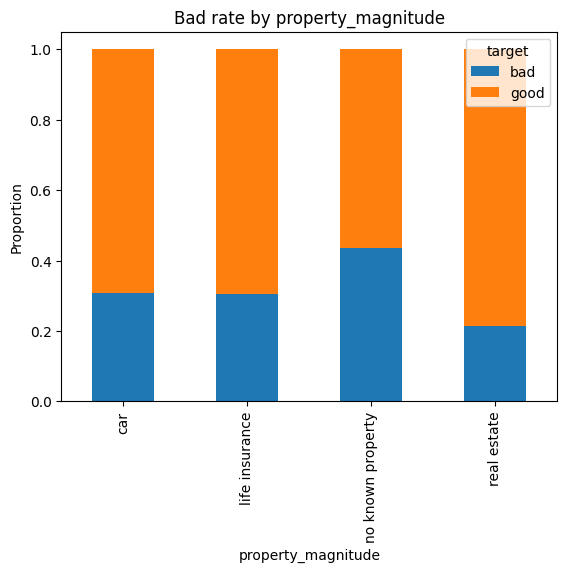

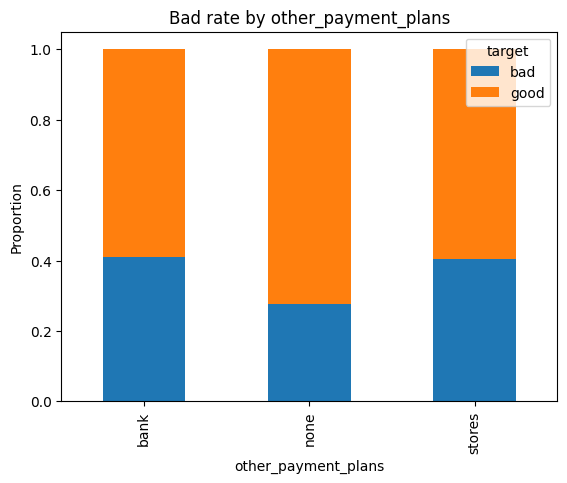

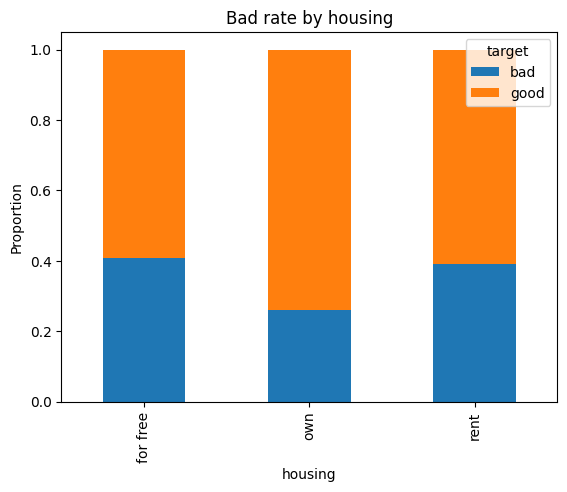

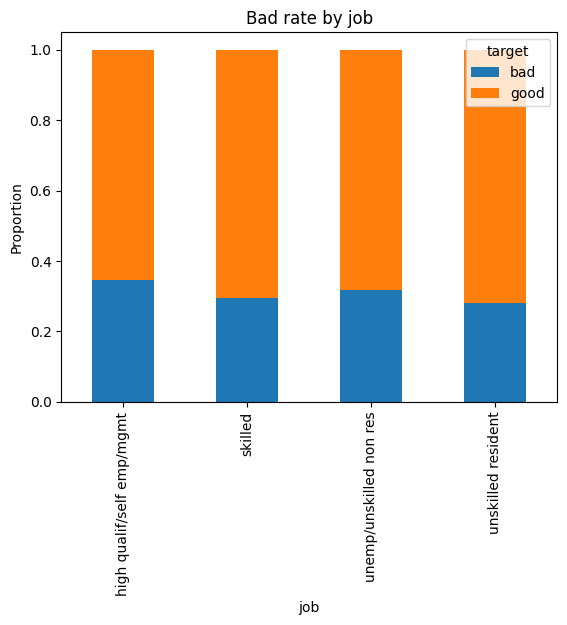

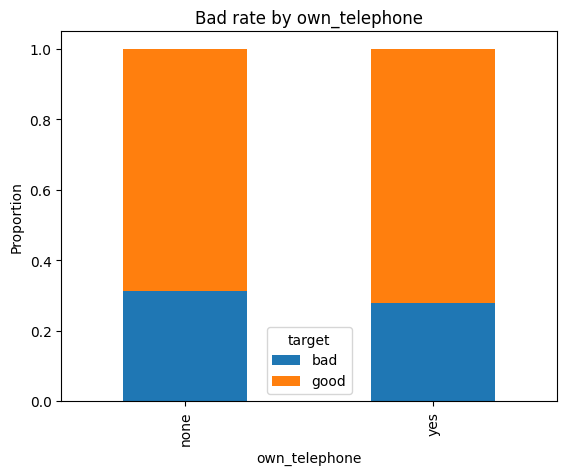

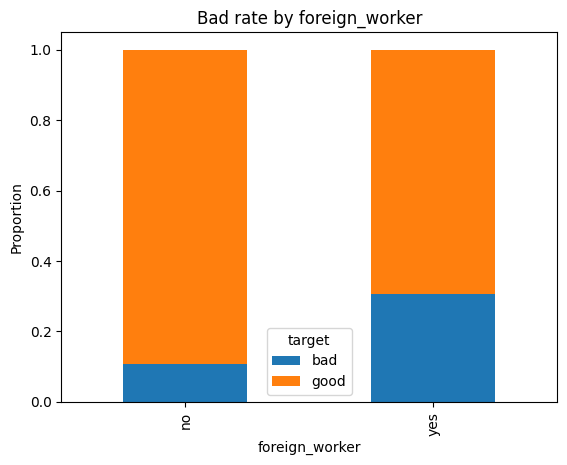

In [60]:
for col in cat_cols:
    pd.crosstab(df[col], df['target'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(f'Bad rate by {col}')
    plt.ylabel('Proportion')
    plt.show()

## Research Questions and Answers

1. What is the class distribution?
The dataset is imbalanced (about 70% good, 30% bad).

2. Which features are most informative for risk?
Credit amount and duration show the strongest relation with target in EDA.

3. Are there data quality issues?
No major missing-value or duplicate issues were found.

4. What preprocessing is justified?
Log transform on skewed numeric features, scaling for numeric variables, and categorical encoding (ordinal + one-hot).

5. Which baseline models perform best?
Logistic Regression, Random Forest, and XGBoost give similar baseline performance; results suggest more gain will come from feature engineering and threshold tuning than adding many new models.

## EDA Conclusions

- The target class is imbalanced: about 70% good payers and 30% bad payers.
- `credit_amount` and `duration` appear to be the most informative numeric features for default risk.
- `credit_amount` is right-skewed and contains outliers, so a log transform is justified later.
- There are no major missing-value or duplicate issues, so the dataset is clean enough to move forward.
- The strongest EDA findings are hypotheses; the final model comparison and business interpretation are in notebook 03.

## Next steps, preprocessing

The next notebook converts these findings into a reproducible preprocessing pipeline and model-ready data.

We will do:
- Log transform skewd features like `credit_amount`, so we dont have problem with linear models
- Apply `StandardScaler` to numerical variables, so they have mean $0$ and standard deviation $1$
- Encode categorical variables. Nominal with `OneHotEncoder` and ordinal with `OrdinalEncoder`